# Markeing Analytics

## Objective

- Goal: analyze customer behavior and spending patterns
- Identify factors influencing revenue and campaign response

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Data Loading & Cleaning

In [2]:
df= pd.read_csv('cleaned_1.csv')

In [3]:
df.shape

(2240, 36)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4    Income              2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Total_Spend,Total_Purchases,Web_revenue,Store_revenue,Catalog_revenue,Inc_group,Age,Age_group,Country
0,0,1985,Graduation,Married,70951.0,0,0,2013-05-04,66,239,...,0,1198,16,224.63,673.88,299.50,Lower middle,41,40-55,Saudi Arabia
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,0,577,17,237.59,237.59,101.82,Lower middle,65,55-70,Canada
2,9,1975,Master,Single,46098.0,1,1,2012-08-18,86,57,...,0,120,7,51.43,34.29,34.29,Low income,51,40-55,Canada
3,13,1947,PhD,Widow,25358.0,0,1,2013-07-22,57,19,...,0,32,4,8.00,24.00,0.00,Low income,79,70+,Saudi Arabia
4,17,1971,PhD,Married,60491.0,0,1,2013-09-06,81,637,...,0,1028,24,257.00,299.83,471.17,Lower middle,55,55-70,Spain


In [8]:
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
 Income                0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Response               0
Complain               0
Total_Spend            0
Total_Purchases        0
Web_revenue            0
Store_revenue          0
Catalog_revenue        0
Inc_group              0
Age                    0
Age_group              0
Country                0
dtype: int64

Dataset is mostly clean; no missing values as its already done using Excel.

In [16]:
# Rename ' Income' with 'Income'
df.rename(columns={" Income ": "Income"}, inplace=True)

## EDA & Visualizations

### Age Distribution

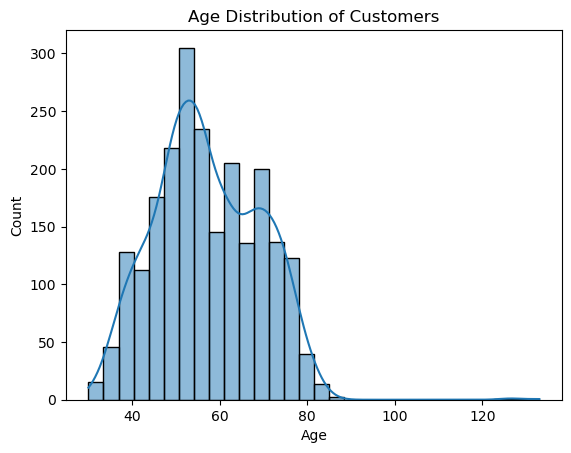

In [9]:
plt.figure()
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Most customers fall in middle-age group, suggesting marketing should target working professionals.

### Income Distribution

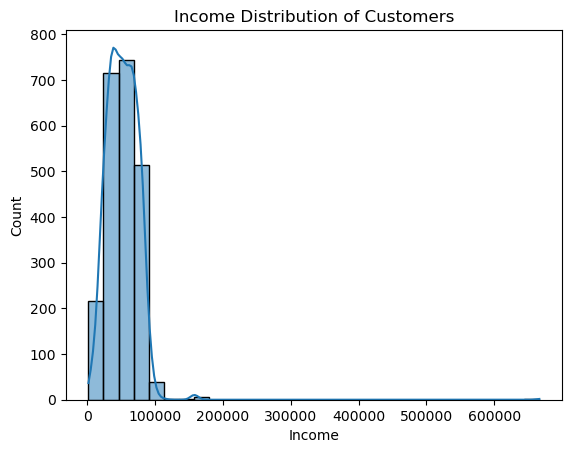

In [17]:
plt.figure()
sns.histplot(df["Income"], bins=30, kde=True)
plt.title("Income Distribution of Customers")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

Income is concentrated in mid-range, meaning premium pricing may limit conversions.

### Spend Distribution

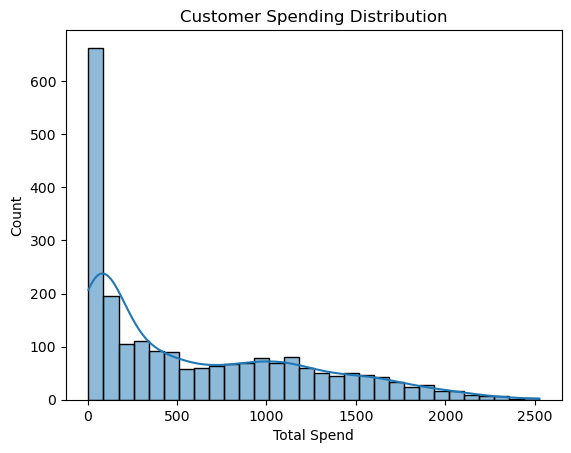

In [15]:
plt.figure()
sns.histplot(df["Total_Spend"], bins=30, kde=True)
plt.title("Customer Spending Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Count")
plt.show()

Most customers spend moderately, with few high spenders driving revenue.

### Revenue Contribution by Channel

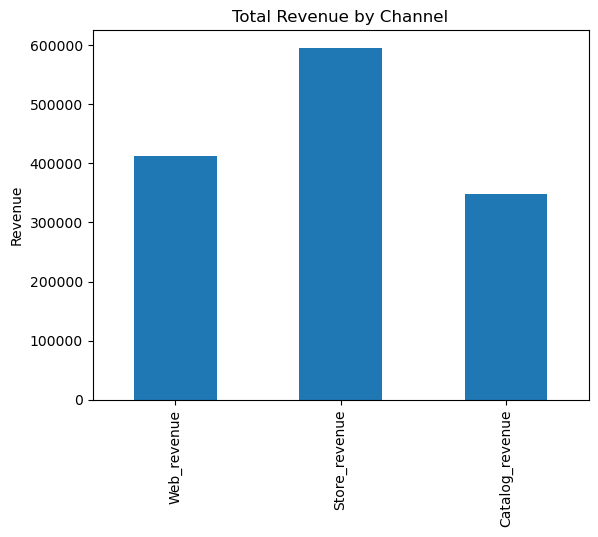

In [21]:
channel_rev = df[['Web_revenue','Store_revenue','Catalog_revenue']].sum()

channel_rev.plot(kind='bar')
plt.title("Total Revenue by Channel")
plt.ylabel("Revenue")
plt.show()

Store purchases contribute the highest revenue, indicating offline channels remain the strongest sales driver.

### Correlation Matrix

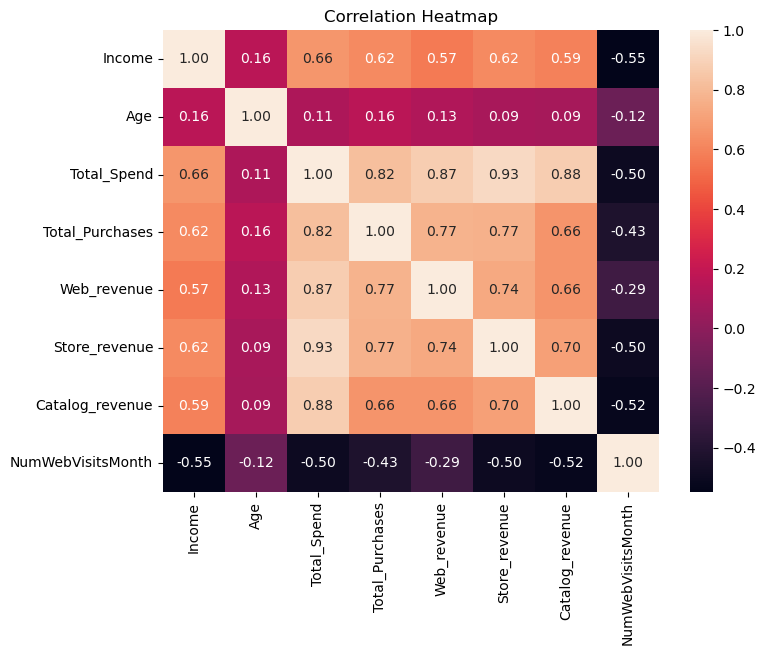

In [19]:
num_cols = [
    'Income','Age','Total_Spend','Total_Purchases',
    'Web_revenue','Store_revenue','Catalog_revenue',
    'NumWebVisitsMonth'
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Income strongly influences total spend and purchases, indicating purchasing power is the main driver of revenue.

### Spend Distribution by Income wise

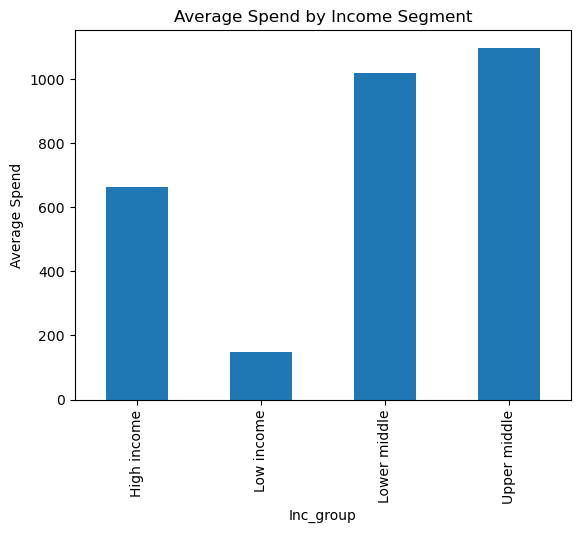

In [20]:
segment_spend = df.groupby('Inc_group')['Total_Spend'].mean()

segment_spend.plot(kind='bar')
plt.title("Average Spend by Income Segment")
plt.ylabel("Average Spend")
plt.show()

Middle-income customers generate the highest average spend, making them the most valuable segment for marketing focus.

## Key Findings

- Store purchases contribute the largest share of revenue, followed by catalog, while web sales lag behind.
- Middle-aged and older customers spend more on average than younger customers.
- Upper and lower middle income groups generate most of the revenue because they form the majority of customers.
- Campaign response rate (~15%) shows marketing is moderately effective but still has room for improvement.
- Customer spending is far lower than income levels, indicating unused purchasing potential.

## Business Actions

- Strengthen store-based promotions and loyalty programs since physical stores drive the most revenue.
- Improve website experience and digital campaigns to increase online purchases.
- Focus marketing on middle-aged, mid-income customers — they deliver the best revenue impact.
- Use targeted offers to increase spending per customer rather than only acquiring new users.
- Segment campaigns by past spending behavior to improve response rate.

## Conclusion

The analysis shows that revenue growth depends more on improving customer spending and channel strategy than expanding customer count. By focusing on high-value segments and optimizing underperforming channels like web sales, the business can significantly improve marketing ROI and overall revenue.